# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01
_PVAL_FLOOR=10**-6

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Air!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

In [ ]:
from bowtie_plot_functions import plot_bowtie_blocks, plot_bowtie_fluxes, _add_colorbar
from bowtie_plot_functions import _fdr as fdr

## Load data

In [14]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
GUARINO_FOLDER=HOME+'guarino_files/'
BIPARTITE_FOLDER_1=HOME+'BiDCM/'
BIPARTITE_FOLDER_2=HOME+'BiDCM2/'
PLOT_FOLDER=HOME+'plots/'

## Looking into the abyss

In [15]:
guarino_files=[file for file in os.listdir(GUARINO_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

In [16]:
bipartite_files_1=[file for file in os.listdir(BIPARTITE_FOLDER_1) if not file.startswith('.')]
bipartite_files_1.sort()
bipartite_files_1
bipartite_files_2=[file for file in os.listdir(BIPARTITE_FOLDER_2) if not file.startswith('.')]
bipartite_files_2.sort()
bipartite_files_2

['crisi_dico_0_bowtie_flows.csv',
 'crisi_dico_0_bowtie_flows_recomputed_sectors.csv',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_flows.csv',
 'crisi_dico_1_bowtie_flows_recomputed_sectors.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_flows.csv',
 'crisi_dico_2_bowtie_flows_recomputed_sectors.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_flows.csv',
 'crisi_dico_3_bowtie_flows_recomputed_sectors.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_flows.csv',
 'crisi_dico_4_bowtie_flows_recomputed_sectors.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_0_bowtie_flows.csv',
 'ita_elections_dico_0_bowtie_flows_recomputed_sectors.csv',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_flows.csv',
 'ita_elections_dico_1_bowtie_flows_recomputed_sectors.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_flows.csv',
 'ita_elections_dico_2_bowtie_flows_recomputed_sectors.csv',
 '

### Name of the various dicos

In [17]:
guarino_files[0]

'all_dico_labels.txt'

In [18]:
with open(GUARINO_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()


In [19]:
def parse_dico_names(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip().split() for line in f]
        # such a command creates a list
        # in which each element is a list of tokens of a line in the file
        # remarkably, there is an empty element
        # before each dataset name
        

    result = {}
    current_key = None

    for tokens in lines:
        if not tokens:
            current_key = None
        elif current_key is None:
            # prima riga non vuota del gruppo: nome del dataset
            current_key = tokens[0]
            result[current_key] = {}
        else:
            # riga tipo ['5:', 'journalists', '&', 'Media']
            idx = int(tokens[0].rstrip(':'))
            label = ' '.join(tokens[1:])
            result[current_key][idx] = label

    return result

In [20]:
cacca=parse_dico_names(GUARINO_FOLDER+guarino_files[0])

In [21]:
with open(GUARINO_FOLDER+guarino_files[6], 'rb') as f:
    cacca = pickle.load(f)

In [22]:
cacca

{1: 'Lega & FDI & FI',
 2: 'M5S & journalists',
 0: 'journalists & IV & Media & Azione & +Europa',
 4: 'Media & journalists',
 3: 'PD'}

The pickle is what I need.

# Functions

### guarino2dict_blocks

In [23]:
def guarino2dict_blocks(dataset, dico, folder):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_sizes.csv'
    # load the data
    BIPARTITE_FOLDER=BIPARTITE_FOLDER_1 if folder==1 else BIPARTITE_FOLDER_2
    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=int, skip_header=1)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)
    header=[str(h) for h in header]
    # load the "monopartite" dict
    block_dict_0, flux_dict_0 = ppmf(dataset, dico)
    
    block_dict_bipartite={}

    guarino_translator={'LSCC':'SCC', 'IN-TENDRILS':'INTENDRILS', 'OUT-TENDRILS':'OUTTENDRILS'}

    for i, name in enumerate(header):
        key=guarino_translator.get(name, name)
        block_dict_bipartite[key] = {}
        block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
        block_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
        block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
        _median=np.median(block_dict_bipartite[key]['sample'])
        if _median>block_dict_bipartite[key]['obs']:
            block_dict_bipartite[key]['tail']='left'
        else:
            block_dict_bipartite[key]['tail']='right'
    return block_dict_bipartite, block_dict_0, flux_dict_0



### guarino2dict_fluxes

In [24]:
def guarino2dict_fluxes(dataset, dico, folder, recomputed=False):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_flows.csv'
    # load the data
    if folder==2:
        BIPARTITE_FOLDER=BIPARTITE_FOLDER_2
        if recomputed:
            file_name=f'{dataset}_dico_{dico}_bowtie_flows_recomputed_sectors.csv'
    else:
        BIPARTITE_FOLDER=BIPARTITE_FOLDER_1



    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', skip_header=1)
    cacca=cacca.astype(int)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)

    _, flux_dict_0 = ppmf(dataset, dico)

    flux_dict_bipartite=defaultdict(dict)
    guarino_translator={'LSCC':'SCC', 'IN-TENDRILS':'INTENDRILS', 'OUT-TENDRILS':'OUTTENDRILS'}

    

    for i, name in enumerate(header):
        source, target = name.split('->')
        # translate the source and target to match the keys in flux_dict_0
        source = guarino_translator.get(source, source)
        target = guarino_translator.get(target, target)
        key = '->'.join([source, target])

        flux_dict_bipartite[key]['obs']=flux_dict_0[key]['obs']
        flux_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=flux_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=flux_dict_bipartite[key]['obs'])
        flux_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(flux_dict_bipartite[key]['sample'])
        _median=np.median(flux_dict_bipartite[key]['sample'])
        if _median>flux_dict_bipartite[key]['obs']:
            flux_dict_bipartite[key]['tail']='left'
        else:
            flux_dict_bipartite[key]['tail']='right'
        
    return flux_dict_bipartite, flux_dict_0
    

### ppmf: pre-processing my files

In [25]:
def ppmf(dataset, dico):
    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_blocks_1.pkl', 'rb') as f:
        block_dict_1 = pickle.load(f)

    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_fluxes_1.pkl', 'rb') as f:
        flux_dict_1 = pickle.load(f)

    for key, value in block_dict_1.items():
        block_dict_1[key]['mean_sim']=np.mean(value['count_sample'])
        block_dict_1[key]['std_sim']=np.std(value['count_sample'])    
        if np.median(value['count_sample']) > block_dict_1[key]['obs']:
            block_dict_1[key]['tail']='left'
        else:
            block_dict_1[key]['tail']='right'
        
    for key, value in flux_dict_1.items():
        flux_dict_1[key]['mean_sim']=np.mean(value['count_sample'])
        flux_dict_1[key]['std_sim']=np.std(value['count_sample'])    
        if np.median(value['count_sample']) > flux_dict_1[key]['obs']:
            flux_dict_1[key]['tail']='left'
        else:
            flux_dict_1[key]['tail']='right'    

    return block_dict_1, flux_dict_1


# Bipartite 1, Bipartite 2

## Ita elections

### Prelude

In [26]:
labels_file=[file for file in os.listdir(GUARINO_FOLDER) if file.endswith('.pickle') and file.startswith('ita')][0]

In [27]:
labels=pickle.load(open(GUARINO_FOLDER+labels_file, 'rb'))

In [28]:
labels

{1: 'PD & Media & +Europa & journalists',
 2: 'M5S & Media',
 3: 'journalists & IV & Azione',
 0: 'Lega & FDI & FI',
 4: 'journalists & Media (1)',
 5: 'Media',
 6: 'journalists & Media (2)'}

### Right-wing

In [ ]:
dataset='ita_elections'
dico=0

#### Bowtie

In [ ]:
blocks1=guarino2dict_blocks(dataset, dico, folder=1)
fluxes1=guarino2dict_fluxes(dataset, dico, folder=1)
blocks2=guarino2dict_blocks(dataset, dico, folder=2)
fluxes2=guarino2dict_fluxes(dataset, dico, folder=2)
fluxes2bis=guarino2dict_fluxes(dataset, dico, folder=2, recomputed=True)

In [ ]:
users1=0
for key in blocks1[0].keys():
    users1+=blocks1[0][key]['obs']

In [ ]:
users2=0
for key in blocks2[0].keys():
    users2+=blocks2[0][key]['obs']

In [ ]:
users1, users2

In [ ]:
rts1=0
for key in blocks1[2].keys():
    rts1+=blocks1[2][key]['obs']

In [ ]:
rts2=0
for key in blocks2[2].keys():
    rts2+=blocks2[2][key]['obs']

In [ ]:
rts1, rts2

##### Blocks

In [ ]:
block='SCC'

In [ ]:
plt.vlines(blocks1[0][block]['obs']/users1, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')

plt.hist(blocks1[0][block]['sample']/users1, edgecolor='black', label='1', alpha=.5, density=True)
plt.hist(blocks2[0][block]['sample']/users2, edgecolor='black', label='2', alpha=.5, density=True)

plt.ylim(0, 5*10**2)
plt.title(f'{block}', fontsize=18)
plt.legend()
plt.show()

In [ ]:
_flux='SCC->OUT'

In [ ]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes1[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)

plt.hist(fluxes1[0][_flux]['sample'], bins=7, edgecolor='black', label='1', density=True, zorder=2)

plt.hist(fluxes2[0][_flux]['sample'], bins=7, edgecolor='black', label='2', density=True,  zorder=2)

plt.hist(fluxes2bis[0][_flux]['sample'], bins=7, edgecolor='black', label='2, recomputed', density=True, zorder=2)

plt.ylim(0, 2*10**-4)
#plt.xscale('log')

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex}', fontsize=18)
plt.legend(fontsize=14)
plt.show()


## Crisis
i.e. the Guarino benchmark

### Prelude

In [30]:
labels_file=[file for file in os.listdir(GUARINO_FOLDER) if file.endswith('.pickle') and file.startswith('crisi')][0]

In [31]:
labels=pickle.load(open(GUARINO_FOLDER+labels_file, 'rb'))

In [32]:
labels

{1: 'Lega & FDI & FI',
 2: 'M5S & journalists',
 0: 'journalists & IV & Media & Azione & +Europa',
 4: 'Media & journalists',
 3: 'PD'}

### Italia Viva

In [33]:
dataset='crisi'
dico=0

#### Bowtie

In [34]:
blocks1=guarino2dict_blocks(dataset, dico, folder=1)
fluxes1=guarino2dict_fluxes(dataset, dico, folder=1)
blocks2=guarino2dict_blocks(dataset, dico, folder=2)
fluxes2=guarino2dict_fluxes(dataset, dico, folder=2)
fluxes2bis=guarino2dict_fluxes(dataset, dico, folder=2, recomputed=True)

In [35]:
users1=0
for key in blocks1[0].keys():
    users1+=blocks1[0][key]['obs']

In [36]:
users2=0
for key in blocks2[0].keys():
    users2+=blocks2[0][key]['obs']

In [37]:
users1, users2

(58832, 58832)

In [38]:
rts1=0
for key in blocks1[2].keys():
    rts1+=blocks1[2][key]['obs']

In [39]:
rts2=0
for key in blocks2[2].keys():
    rts2+=blocks2[2][key]['obs']

In [41]:
rts1, rts1==rts2

(488611, True)

##### Blocks

In [42]:
block='SCC'

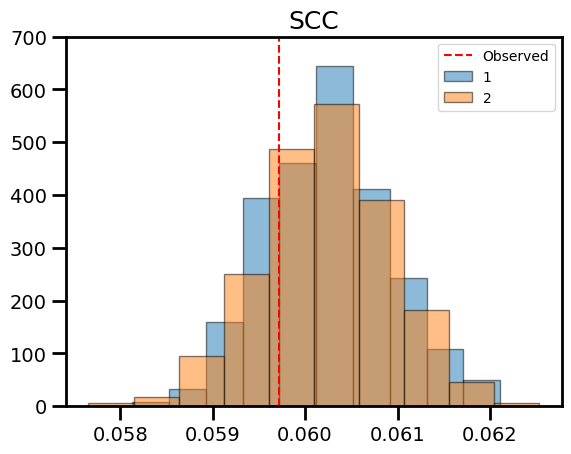

In [45]:
plt.vlines(blocks1[0][block]['obs']/users1, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')

plt.hist(blocks1[0][block]['sample']/users1, edgecolor='black', label='1', alpha=.5, density=True)
plt.hist(blocks2[0][block]['sample']/users2, edgecolor='black', label='2', alpha=.5, density=True)

plt.ylim(0, 7*10**2)
plt.title(f'{block}', fontsize=18)
plt.legend()
plt.show()

In [46]:
_flux='SCC->OUT'

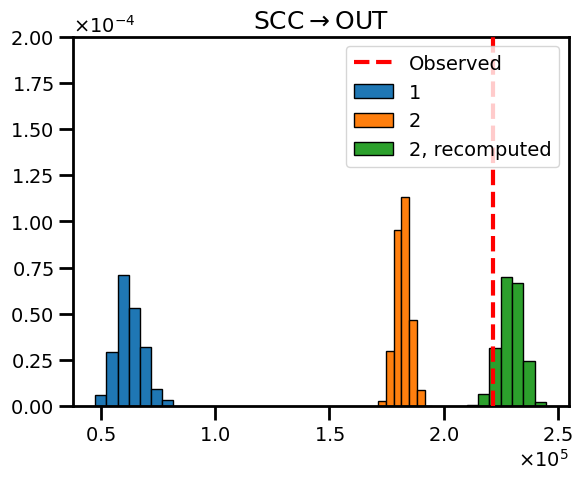

In [47]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes1[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)

plt.hist(fluxes1[0][_flux]['sample'], bins=7, edgecolor='black', label='1', density=True, zorder=2)

plt.hist(fluxes2[0][_flux]['sample'], bins=7, edgecolor='black', label='2', density=True,  zorder=2)

plt.hist(fluxes2bis[0][_flux]['sample'], bins=7, edgecolor='black', label='2, recomputed', density=True, zorder=2)

plt.ylim(0, 2*10**-4)
#plt.xscale('log')

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex}', fontsize=18)
plt.legend(fontsize=14)
plt.show()


In [49]:
np.mean(fluxes1[0][_flux]['sample']), np.mean(fluxes2[0][_flux]['sample']), np.mean(fluxes2bis[0][_flux]['sample'])

(62562.71666666667, 182124.9588, 229436.8744)